<span style='font-size:40px; display:block;'>
<b>
    Ustar filtering
</b>
</br>

---

# **BACKGROUND**

---

Filtering NEE, FN2O and FCH4 using the seasonal ustar thresholds detected with ReddyProc.
The purpose is to exclude fluxes calculated in periods with insufficient turbulence, thus avoiding biases in fluxes.

---

# **IMPORTS**

---

In [1]:
import importlib.metadata
import warnings
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.core.plotting.heatmap_datetime import HeatmapDateTime, HeatmapYearMonth

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.89.0


---

# **LOAD DATA**

---

In [2]:
FILEPATH = r"61.1_FLUXES_L3.2_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet"
maindf = load_parquet(filepath=FILEPATH)
maindf

Loaded .parquet file 61.1_FLUXES_L3.2_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (0.549 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FCH4_L3.1_L3.2_QCF0,Ustar_U16_Thres_reddyproc,Ustar_U50_Thres_reddyproc,Ustar_U84_Thres_reddyproc,NEE_U16_f_reddyproc,NEE_U50_f_reddyproc,NEE_U84_f_reddyproc,GPP_U16_f_reddyproc,GPP_U50_f_reddyproc,GPP_U84_f_reddyproc,Reco_U16_reddyproc,Reco_U50_reddyproc,Reco_U84_reddyproc,LE_f_reddyproc,H_f_reddyproc
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-18 10:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.088025,0.110224,0.135138,1.328996,1.406032,1.406032,0.713445,0.570038,0.634034,2.042440,1.976069,2.040065,28.859389,-9.798868
2023-10-18 11:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.088025,0.110224,0.135138,0.976800,1.066060,1.066060,1.083960,0.927514,0.991358,2.060760,1.993574,2.057418,32.974414,1.894386
2023-10-18 11:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.088025,0.110224,0.135138,0.976800,1.066060,1.066060,1.125441,0.967144,1.030621,2.102240,2.033204,2.096681,32.974414,4.722599
2023-10-18 12:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.088025,0.110224,0.135138,0.732042,0.732042,0.732042,1.393399,1.323323,1.386582,2.125441,2.055365,2.118624,35.773866,11.019241
2023-10-18 12:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.088025,0.110224,0.135138,0.941541,0.941541,0.941541,1.282540,1.208011,1.270240,2.224081,2.149553,2.211782,37.060974,3.519276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 22:45:00,1014.01,1.14117,0.025232,1157.16,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,2.160966,0.073628,0.093021,0.122805,10.095010,10.095010,10.095010,-1.624313,-1.088756,-1.046107,8.470697,9.006254,9.048903,3.778325,-38.997547
2025-06-04 23:15:00,1014.04,1.14156,0.025222,1157.59,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,NaN,0.073628,0.093021,0.122805,8.641342,8.641342,8.641342,-0.191805,0.342690,0.386118,8.449536,8.984032,9.027459,-0.947239,-39.849475
2025-06-04 23:45:00,1013.47,1.14369,0.025185,1159.10,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,NaN,0.073628,0.093021,0.122805,8.664543,8.664543,8.664543,-0.331758,0.196870,0.244553,8.332785,8.861413,8.909096,2.365148,-53.513862


## Select the variables we are interested in

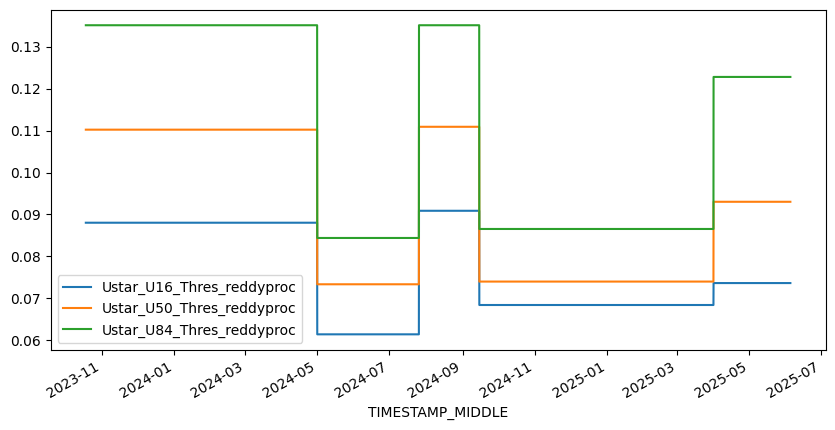

In [3]:
USTAR_SCENARIOS = ['Ustar_U16_Thres_reddyproc', 'Ustar_U50_Thres_reddyproc', 'Ustar_U84_Thres_reddyproc']
maindf[USTAR_SCENARIOS].plot(x_compat=True, figsize=(10, 5));

In [4]:
FLUX_VARS = [c for c in maindf.columns if 'L3.1_L3.2' in c]
TO_BE_FILTERED = ['NEE', 'FN2O', 'FCH4']
VARS_TO_FILTER = [c for c in FLUX_VARS if c.startswith(tuple(TO_BE_FILTERED))]
maindf[VARS_TO_FILTER]

,NEE_L3.1_L3.2_QCF,NEE_L3.1_L3.2_QCF0,FN2O_L3.1_L3.2_QCF,FN2O_L3.1_L3.2_QCF0,FCH4_L3.1_L3.2_QCF,FCH4_L3.1_L3.2_QCF0
TIMESTAMP_MIDDLE,,,,,,
2023-10-18 10:45:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-18 11:15:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-18 11:45:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-18 12:15:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-18 12:45:00,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2025-06-04 22:45:00,10.095010,10.095010,-0.069384,-0.069384,2.160966,2.160966
2025-06-04 23:15:00,8.641342,8.641342,-0.288296,-0.288296,-1.904577,NaN
2025-06-04 23:45:00,8.664543,8.664543,0.220511,0.220511,NaN,NaN


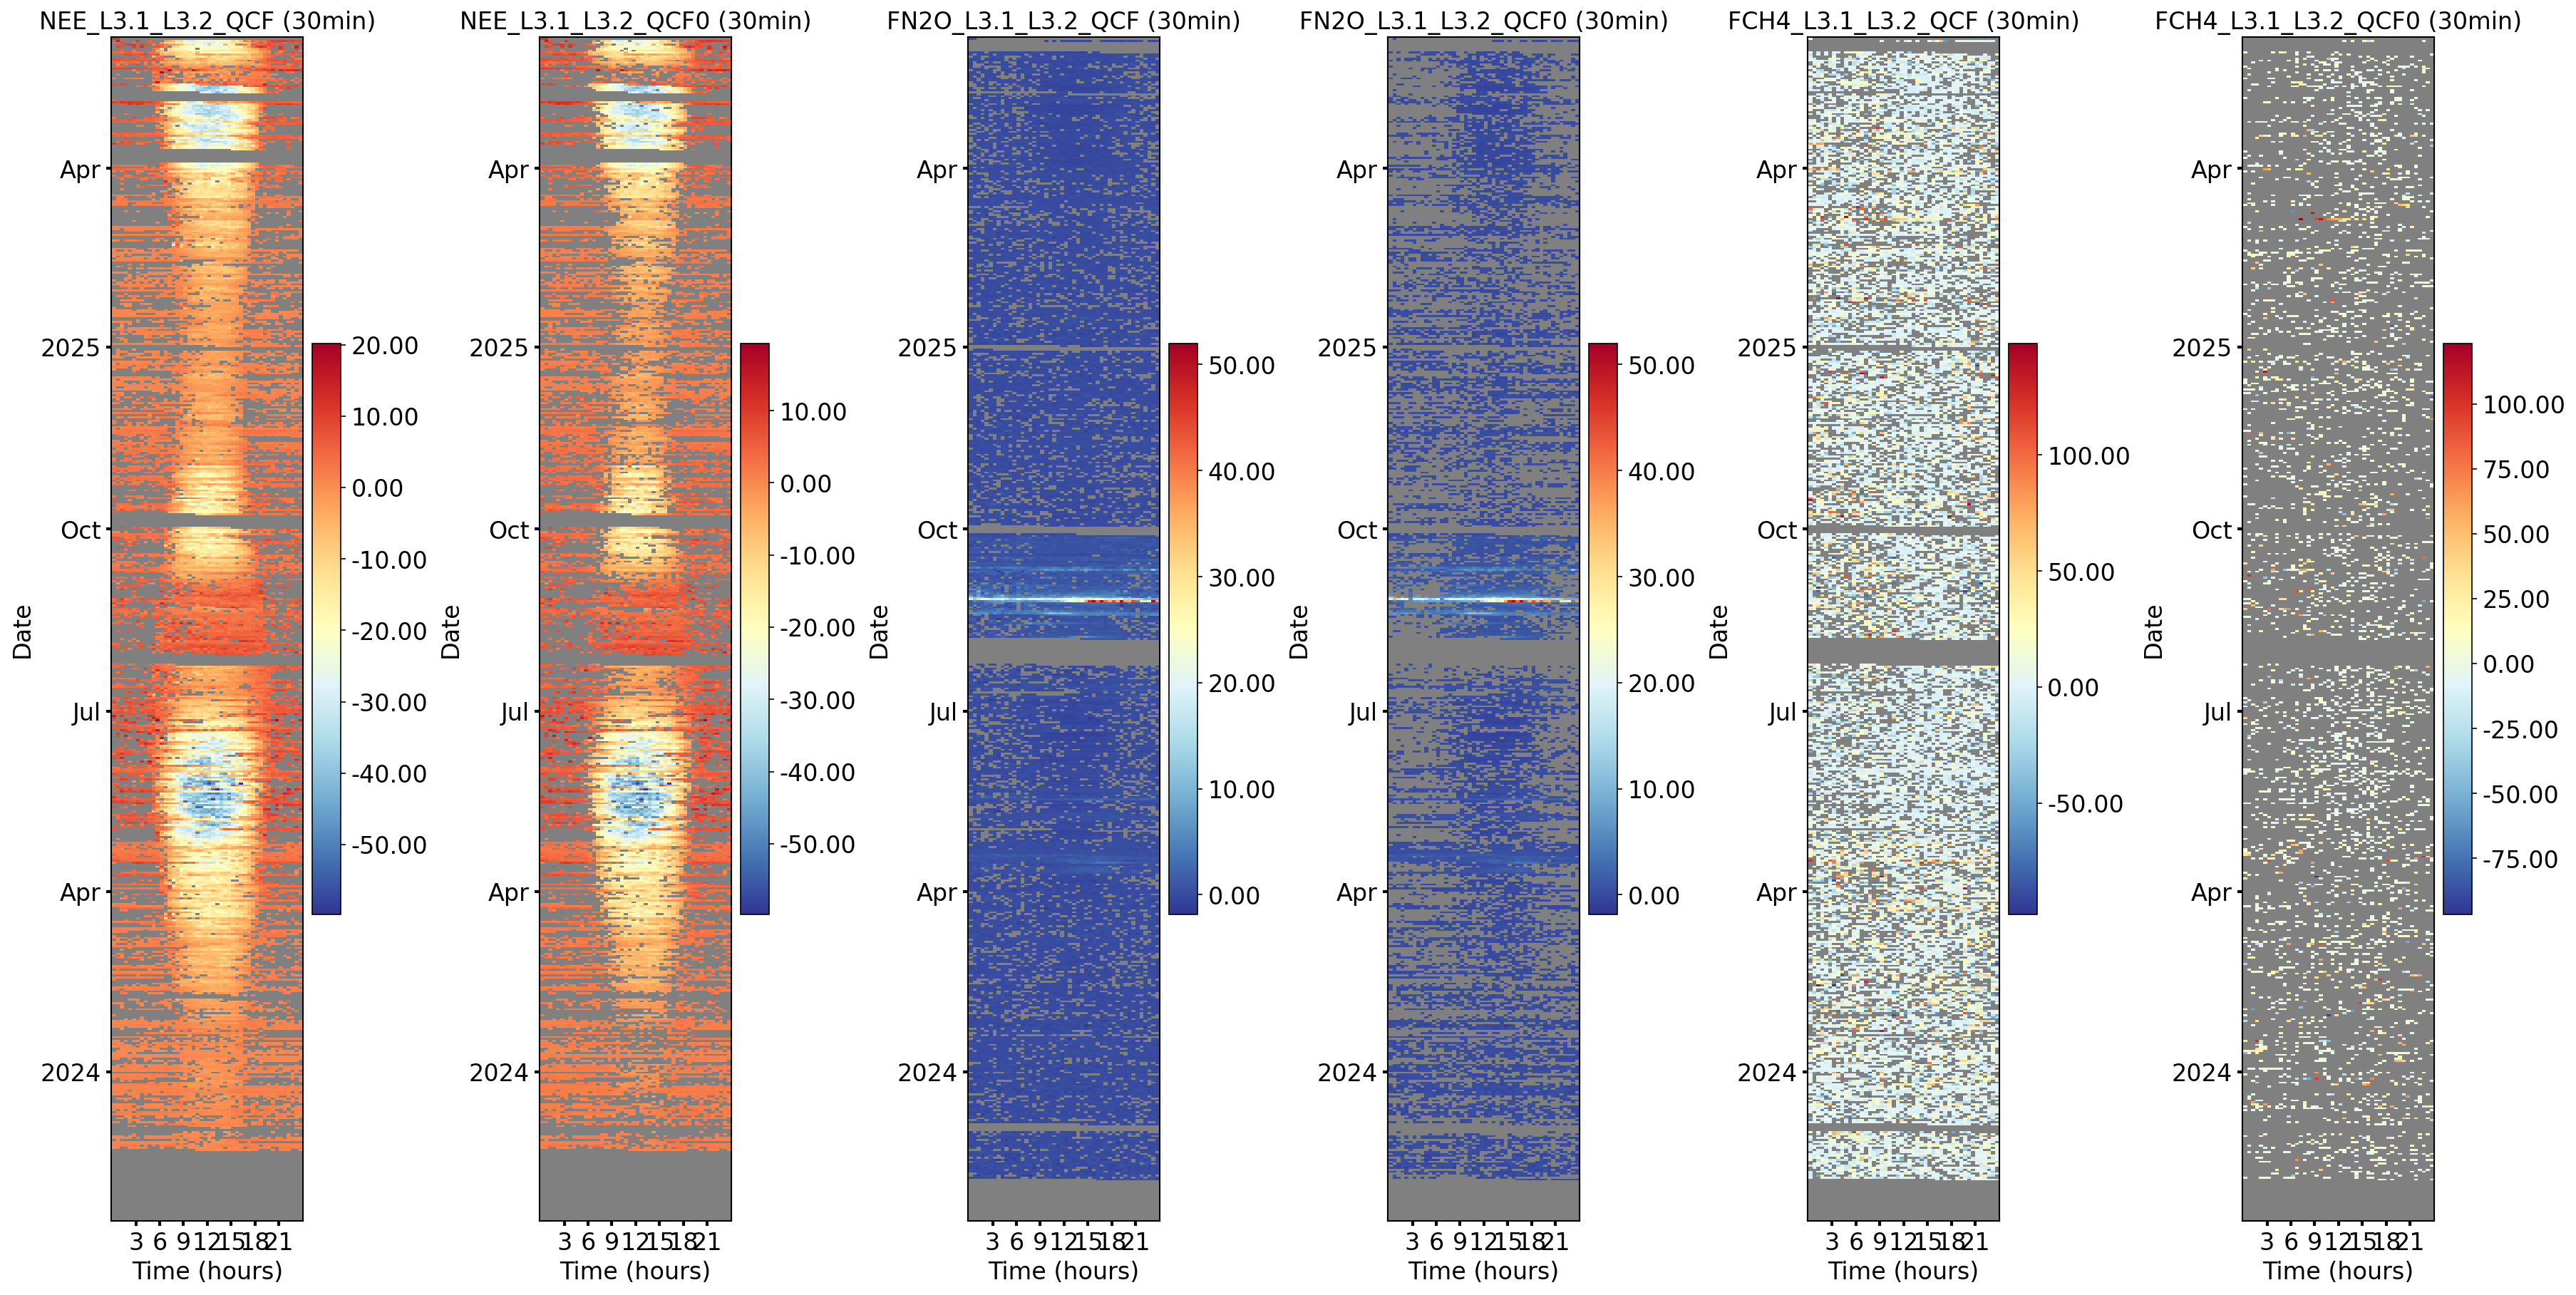

In [5]:
# Plot the fluxes that will be filtered

fig, axs = plt.subplots(ncols=6, nrows=1, figsize=(24, 12), dpi=150, layout="constrained")
axs = axs.flatten()
for ax, var in zip(axs, VARS_TO_FILTER):
    HeatmapDateTime(series=maindf[var], ax=ax).plot()

</br>

</br>

---

# **USTAR FILTERING**

---

In [6]:
df_new = maindf.copy()

for var in VARS_TO_FILTER:
    n_total = df_new[var].notna().sum()   # valid values in original variable
    for cut in USTAR_SCENARIOS:
        CUT = cut[7:9]
        name_var = f"{var.split('_', 1)[0]}_L3.3_CUT_{CUT}_{var.rsplit('_', 1)[-1]}"
        name_flag = f"FLAG_L3.3_CUT_{CUT}_{var.split('_', 1)[0]}_L3.2_{var.rsplit('_', 1)[-1]}_USTAR_TEST"
        # Initialize if new
        if name_var not in df_new:
            df_new[name_var] = np.nan
        if name_flag not in df_new:
            df_new[name_flag] = 0.0
        valid_mask = df_new[var].notna()
        mask = df_new["USTAR"] > df_new[cut]
        df_new.loc[mask & valid_mask, name_var]  = df_new.loc[mask, var]
        df_new.loc[~mask & valid_mask, name_flag] = 2.0
        # Print stats
        n_out = (df_new[name_flag] == 2.0).sum()
        pct   = 100 * n_out / n_total if n_total > 0 else np.nan
        print(f"USTAR threshold CUT_{int(CUT)} removed "
              f"{n_out} values, {pct:.1f}% of {var}")

USTAR threshold CUT_16 removed 1968 values, 11.4% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 2831 values, 16.4% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_84 removed 4000 values, 23.1% of NEE_L3.1_L3.2_QCF
USTAR threshold CUT_16 removed 1486 values, 9.9% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_50 removed 2137 values, 14.3% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_84 removed 3082 values, 20.6% of NEE_L3.1_L3.2_QCF0
USTAR threshold CUT_16 removed 3726 values, 17.4% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 5050 values, 23.6% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_84 removed 6748 values, 31.6% of FN2O_L3.1_L3.2_QCF
USTAR threshold CUT_16 removed 1298 values, 10.5% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_50 removed 1796 values, 14.5% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_84 removed 2539 values, 20.5% of FN2O_L3.1_L3.2_QCF0
USTAR threshold CUT_16 removed 3043 values, 18.4% of FCH4_L3.1_L3.2_QCF
USTAR threshold CUT_50 removed 4133 values, 25.0% of FCH4_L3.1_L3

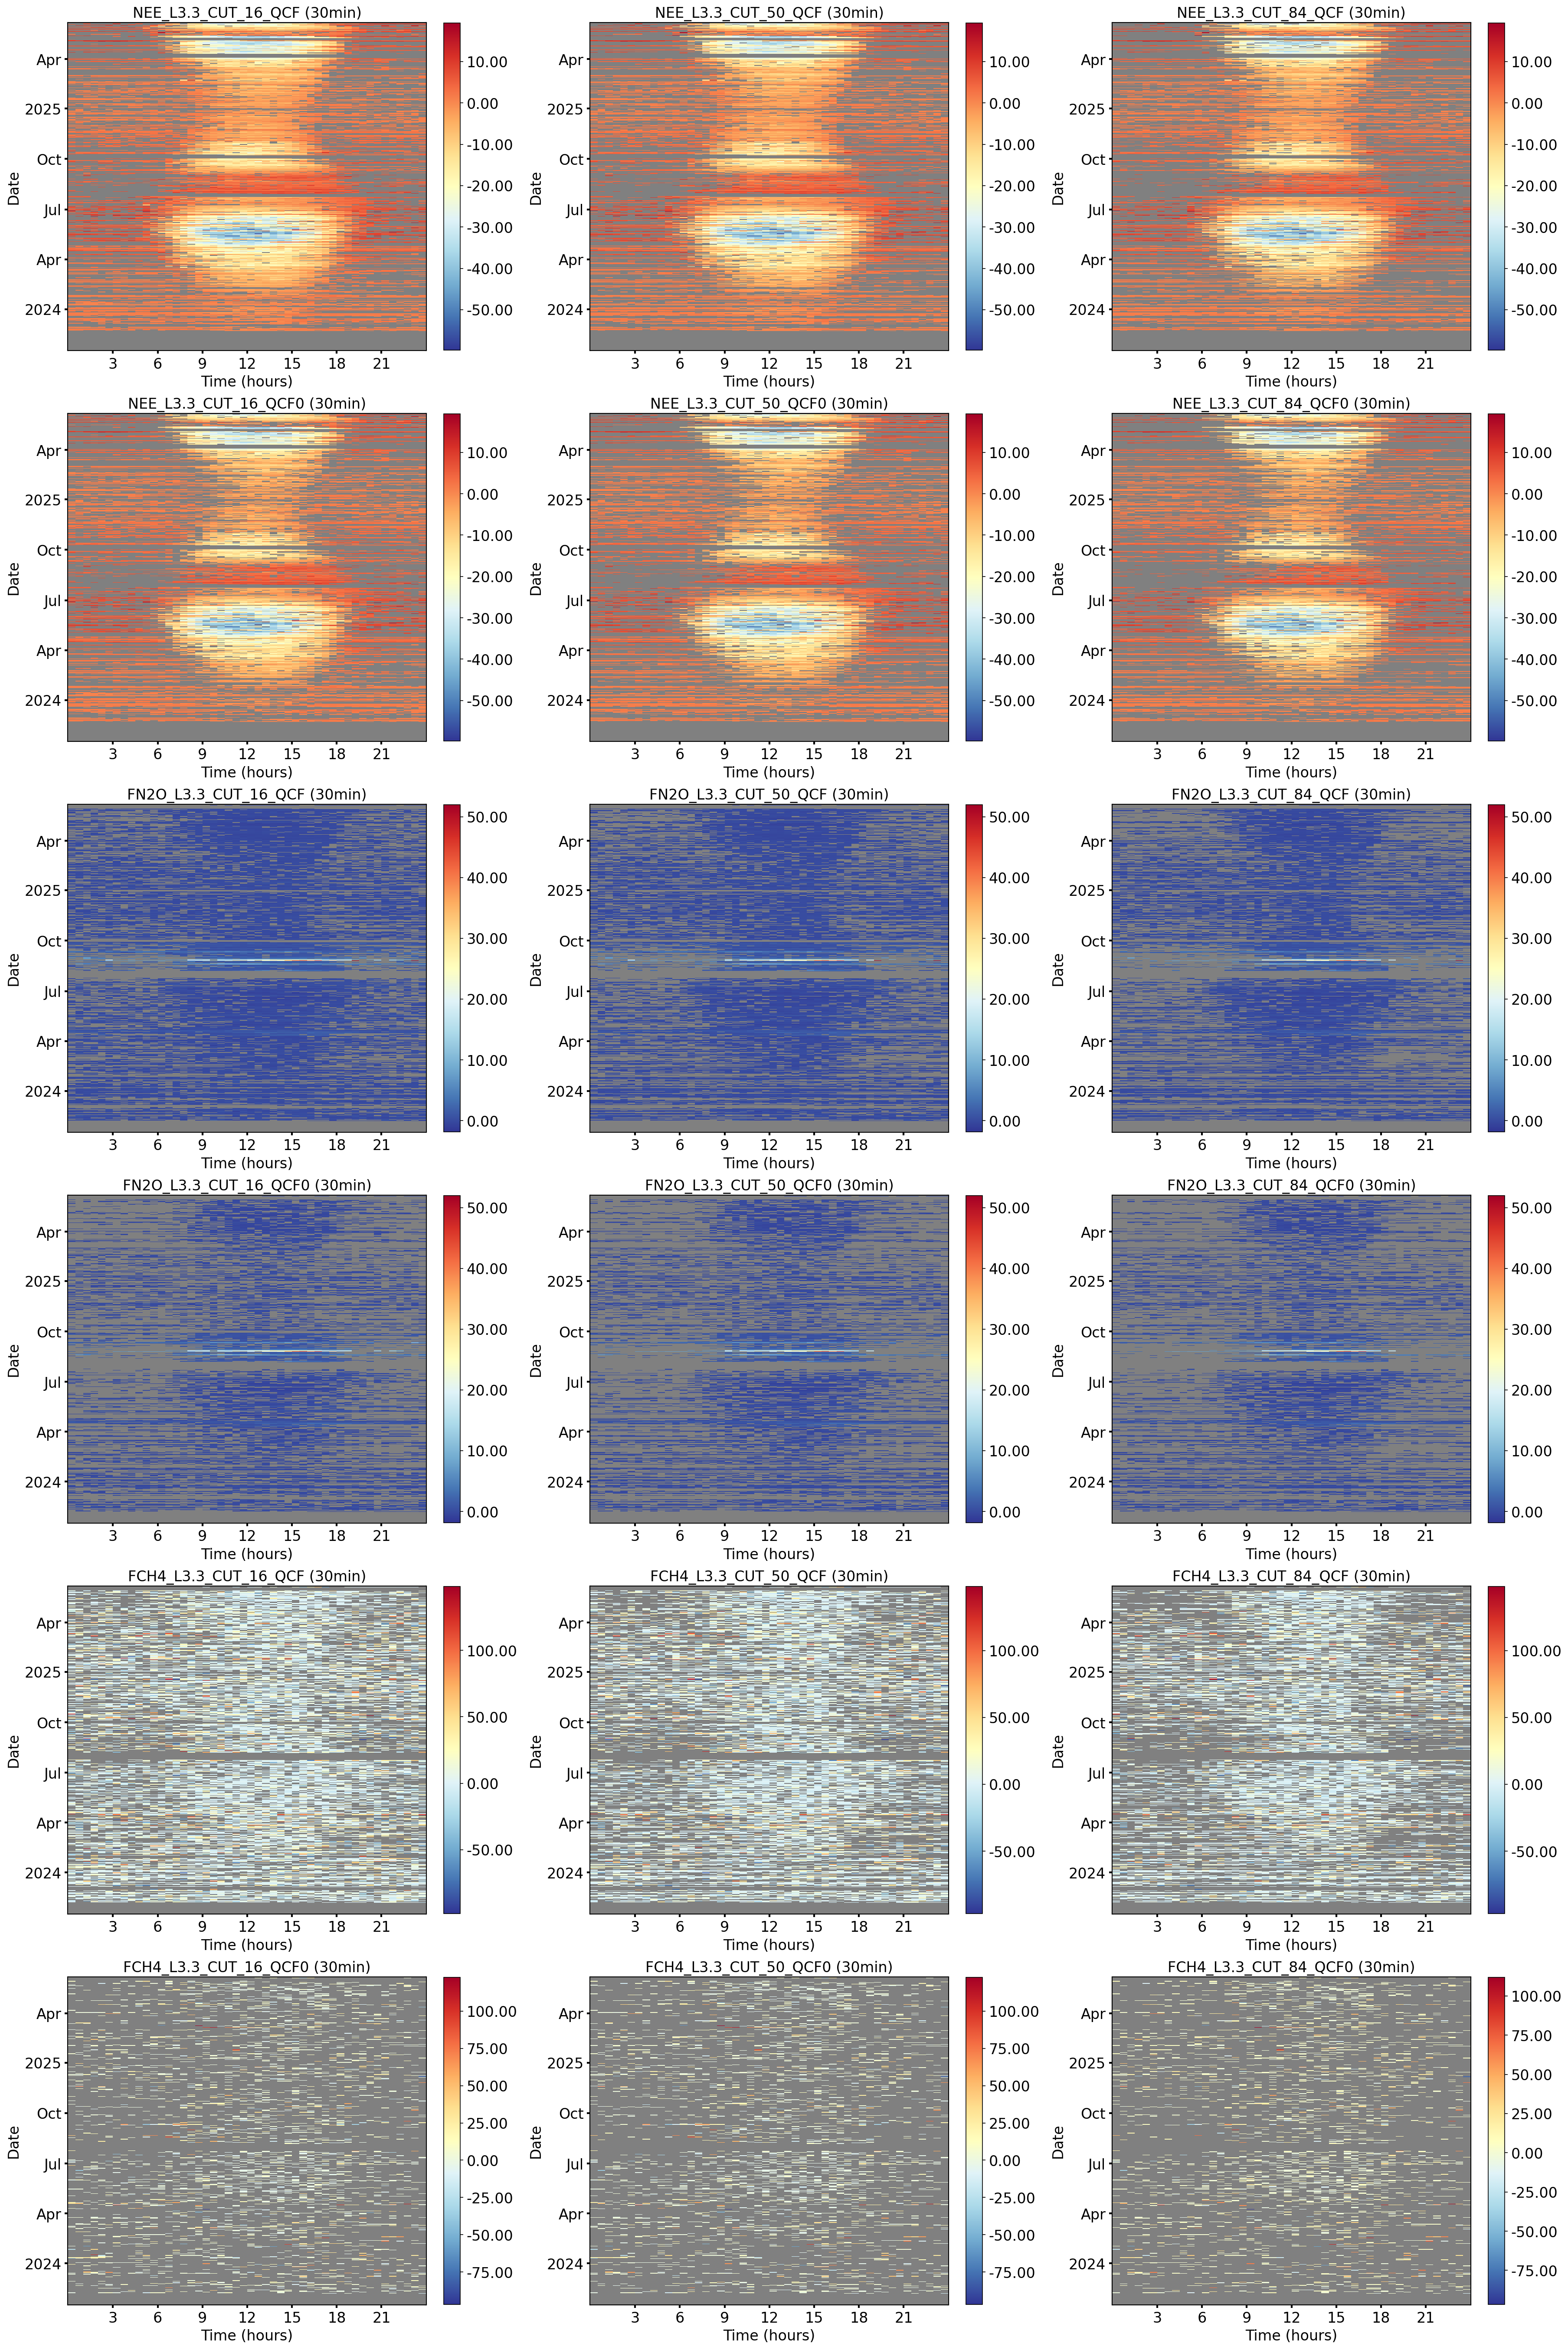

In [7]:
# Plot the ustar-filtered fluxes 
cols_to_plot  = [c for c in df_new.columns if 'CUT' in c and 'TEST' not in c]

fig, axs = plt.subplots(ncols=3, nrows=6, figsize=(24, 36), dpi=150, layout="constrained")
axs = axs.flatten()
for ax, var in zip(axs, cols_to_plot):
    HeatmapDateTime(series=df_new[var], ax=ax).plot()

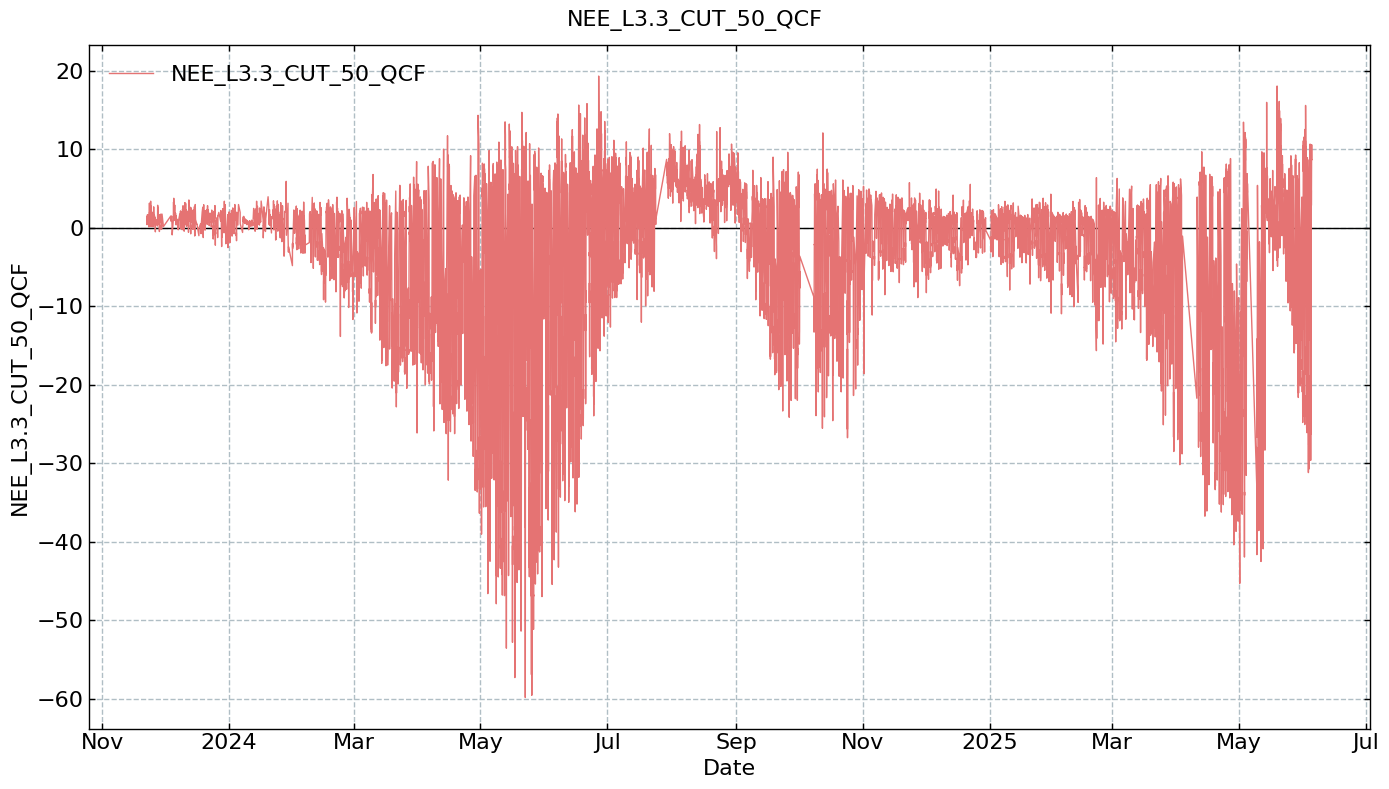

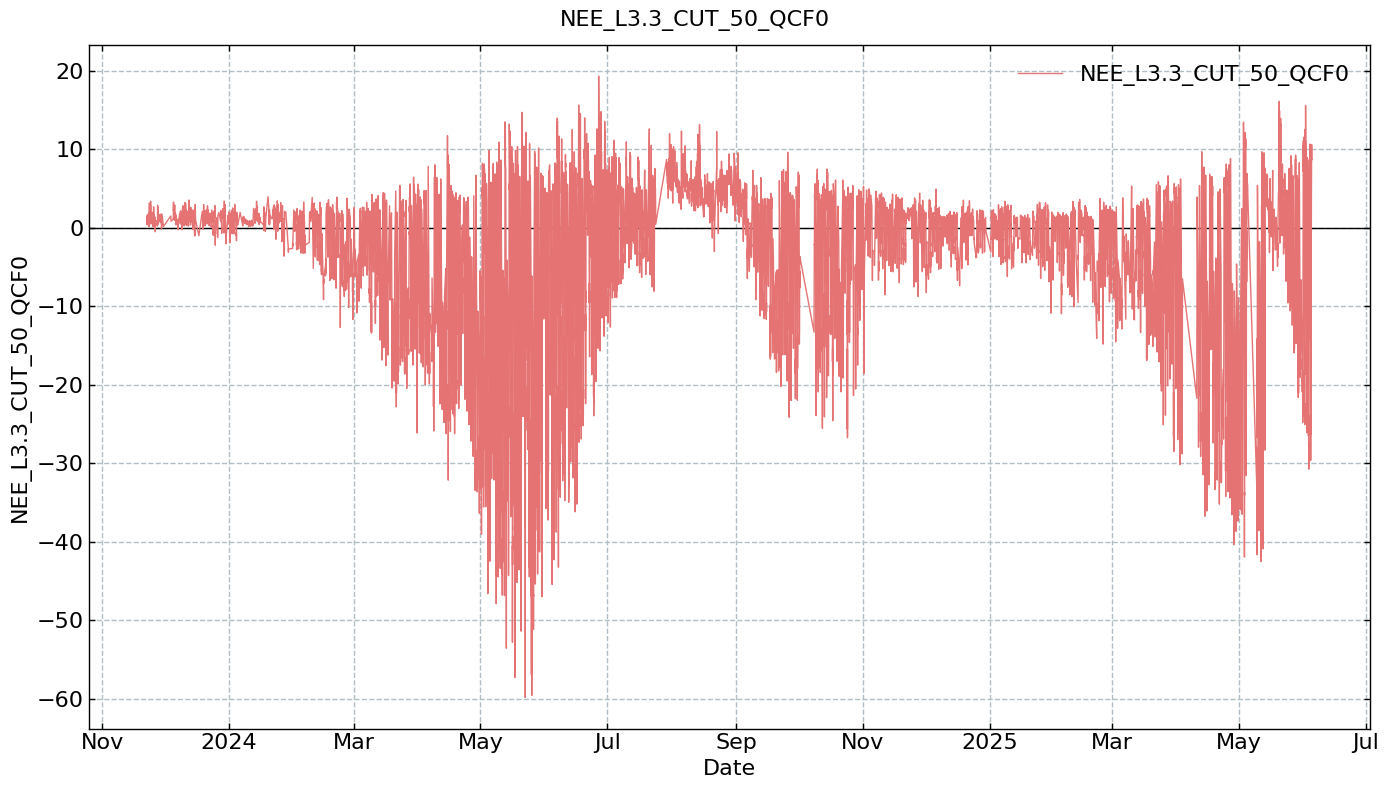

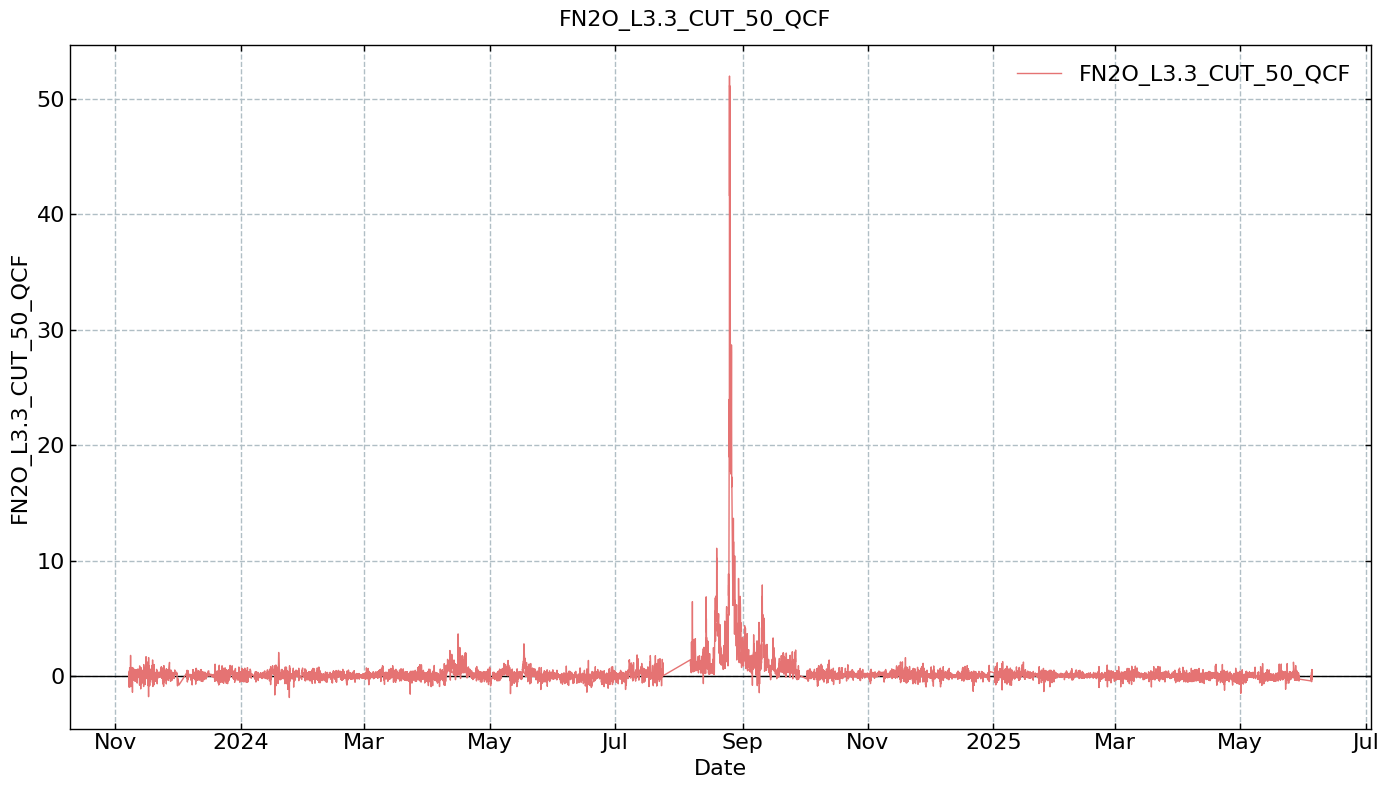

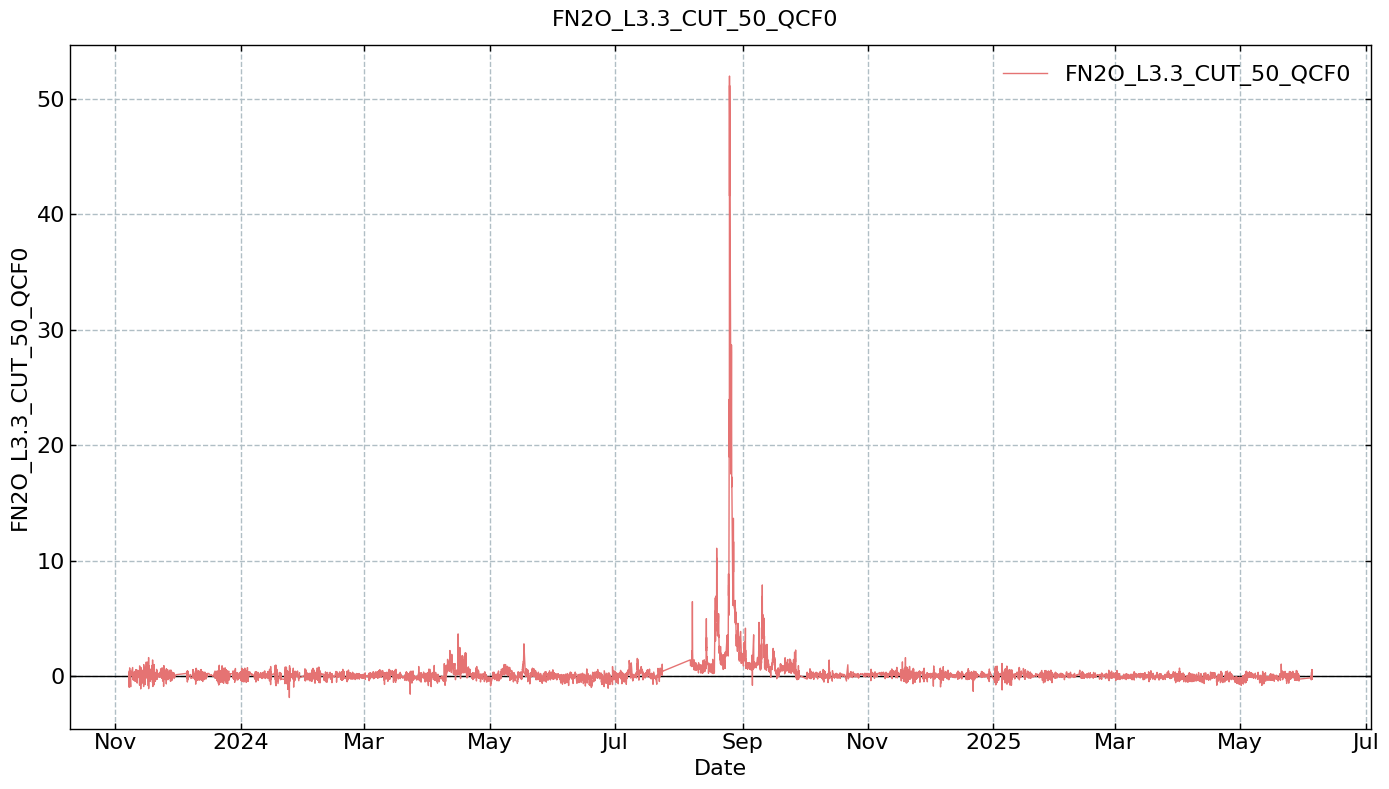

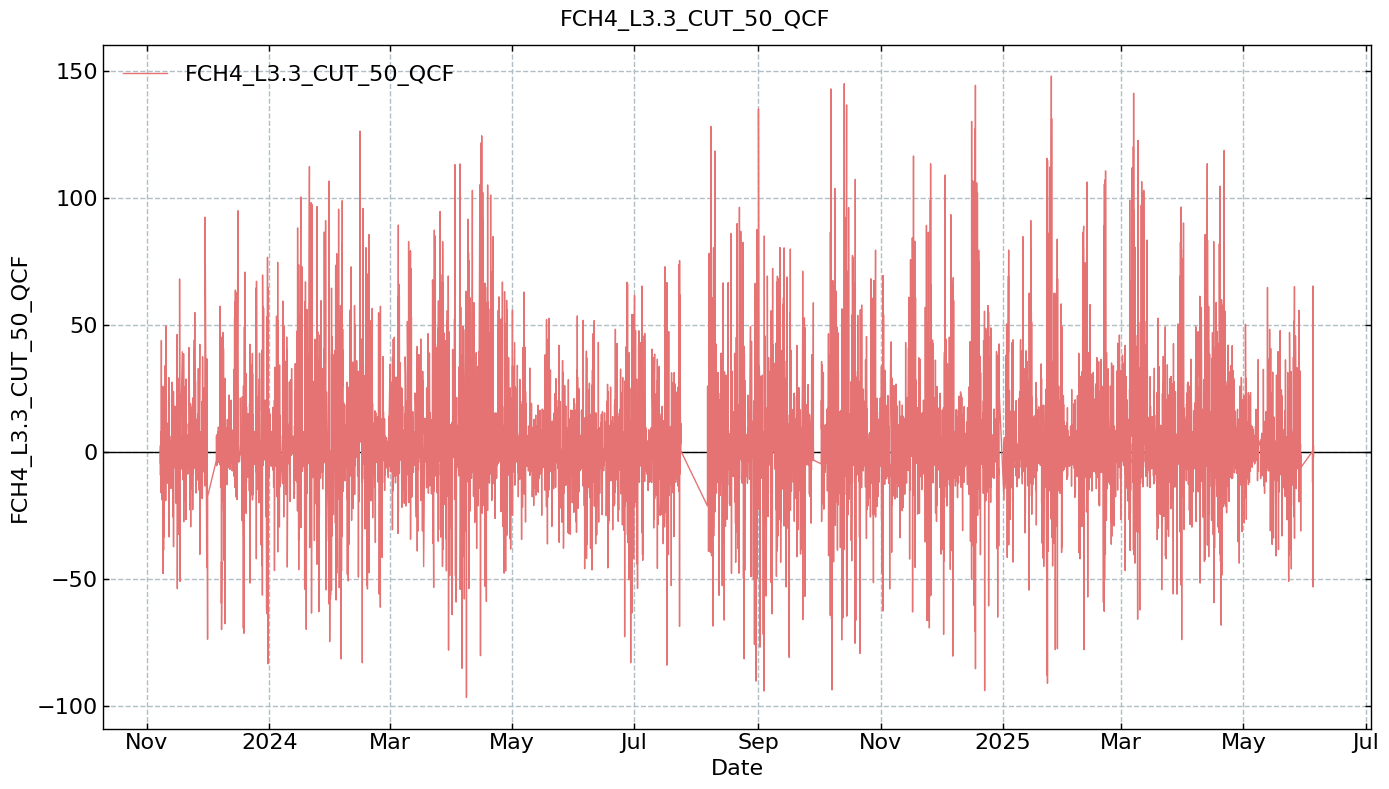

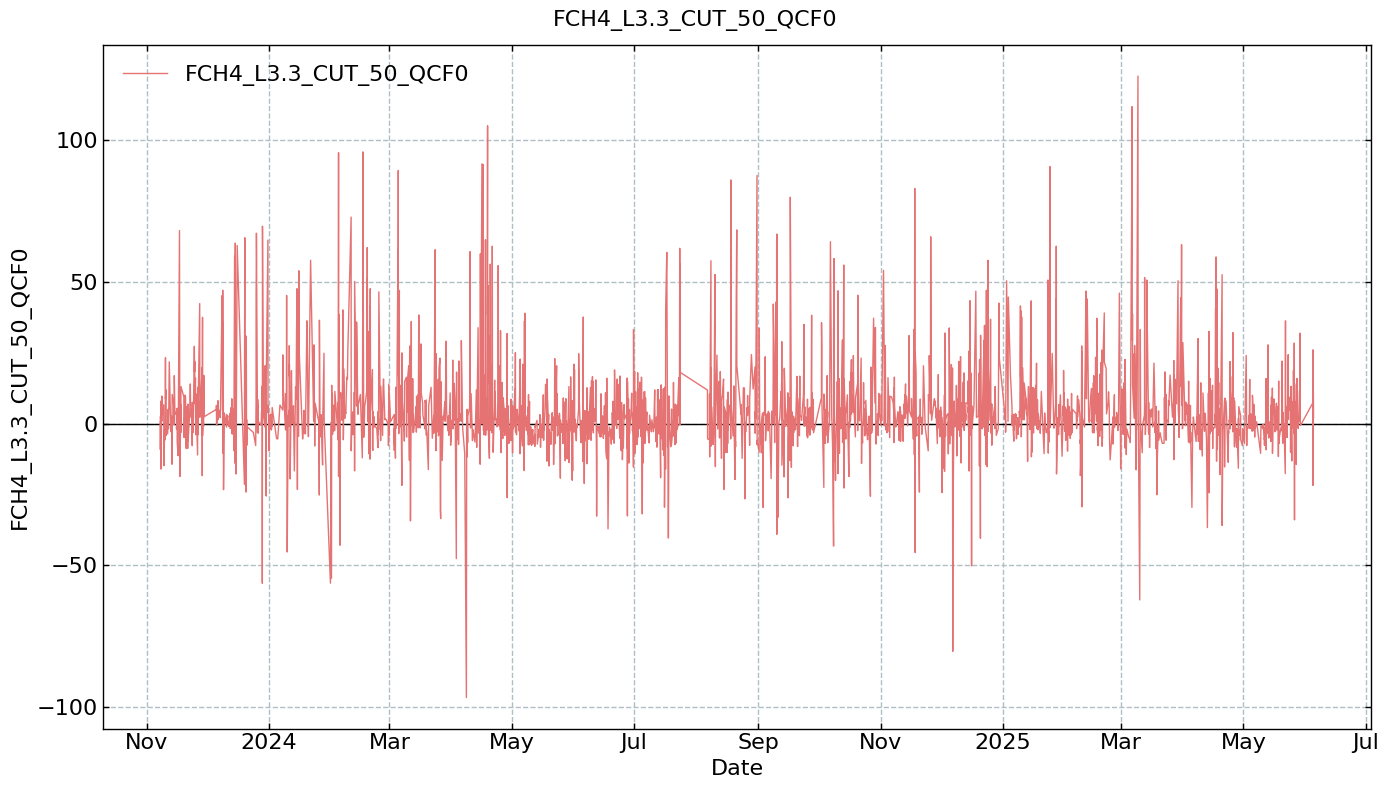

In [8]:
# Plot the variables that will be used in the next steps
for var in [c for c in cols_to_plot if '50' in c]:
    TimeSeries(series=df_new[var]).plot()

</br>

---

# **MERGE**

---

In [9]:
newcols = [c for c in df_new if c not in maindf]
print("NEW VARIABLES FROM USTAR FILTERING:")
[print(f"+ {c}") for c in newcols]
maindf = pd.concat([maindf, df_new[newcols]], axis=1)
maindf

NEW VARIABLES FROM USTAR FILTERING:
+ NEE_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_84_QCF
+ FLAG_L3.3_CUT_84_NEE_L3.2_QCF_USTAR_TEST
+ NEE_L3.3_CUT_16_QCF0
+ FLAG_L3.3_CUT_16_NEE_L3.2_QCF0_USTAR_TEST
+ NEE_L3.3_CUT_50_QCF0
+ FLAG_L3.3_CUT_50_NEE_L3.2_QCF0_USTAR_TEST
+ NEE_L3.3_CUT_84_QCF0
+ FLAG_L3.3_CUT_84_NEE_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_84_QCF
+ FLAG_L3.3_CUT_84_FN2O_L3.2_QCF_USTAR_TEST
+ FN2O_L3.3_CUT_16_QCF0
+ FLAG_L3.3_CUT_16_FN2O_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_50_QCF0
+ FLAG_L3.3_CUT_50_FN2O_L3.2_QCF0_USTAR_TEST
+ FN2O_L3.3_CUT_84_QCF0
+ FLAG_L3.3_CUT_84_FN2O_L3.2_QCF0_USTAR_TEST
+ FCH4_L3.3_CUT_16_QCF
+ FLAG_L3.3_CUT_16_FCH4_L3.2_QCF_USTAR_TEST
+ FCH4_L3.3_CUT_50_QCF
+ FLAG_L3.3_CUT_50_FCH4_L3.2_QCF_USTAR_TEST
+ FCH4_L3.3_CUT_84_QCF
+ F

,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FLAG_L3.3_CUT_50_FN2O_L3.2_QCF0_USTAR_TEST,FN2O_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FN2O_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_16_QCF,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_50_QCF,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_84_QCF,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_16_QCF0,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_50_QCF0,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF0_USTAR_TEST
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-18 10:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-10-18 11:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-10-18 11:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-10-18 12:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-10-18 12:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 22:45:00,1014.01,1.14117,0.025232,1157.16,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,-0.069384,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0,2.160966,0.0
2025-06-04 23:15:00,1014.04,1.14156,0.025222,1157.59,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,-0.288296,0.0,-1.904577,0.0,-1.904577,0.0,-1.904577,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2025-06-04 23:45:00,1013.47,1.14369,0.025185,1159.10,0.0,1.0,0.5,-4.5,2.0,2.0,-4.5,-3.0,-2.5,-2.5,-3.0,...,0.0,0.220511,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0


---

# **EXPORT**

---

In [10]:
filename = "62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC"
save_parquet(data=maindf, filename=filename)

Saved file 62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (4.471 seconds).


'62.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet'

---

# **End of notebook**

---

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-02-10 10:02:29
